# Exploratory Data Analysis (EDA) & Business Intelligence

## Objective
To analyze customer shopping trends and extract insights using EDA and SQL.

In [3]:
from google.colab import files
uploaded = files.upload()

Saving shopping_trends.csv to shopping_trends.csv


## Data Loading

In [4]:
import pandas as pd

df = pd.read_csv("shopping_trends.csv")
df.head()

,Customer ID,Age,Gender,Item Purchased,Category,Purchase Amount (USD),Location,Size,Color,Season,Review Rating,Subscription Status,Payment Method,Shipping Type,Discount Applied,Promo Code Used,Previous Purchases,Preferred Payment Method,Frequency of Purchases
0,1,55,Male,Blouse,Clothing,53,Kentucky,L,Gray,Winter,3.1,Yes,Credit Card,Express,Yes,Yes,14,Venmo,Fortnightly
1,2,19,Male,Sweater,Clothing,64,Maine,L,Maroon,Winter,3.1,Yes,Bank Transfer,Express,Yes,Yes,2,Cash,Fortnightly
2,3,50,Male,Jeans,Clothing,73,Massachusetts,S,Maroon,Spring,3.1,Yes,Cash,Free Shipping,Yes,Yes,23,Credit Card,Weekly
3,4,21,Male,Sandals,Footwear,90,Rhode Island,M,Maroon,Spring,3.5,Yes,PayPal,Next Day Air,Yes,Yes,49,PayPal,Weekly
4,5,45,Male,Blouse,Clothing,49,Oregon,M,Turquoise,Spring,2.7,Yes,Cash,Free Shipping,Yes,Yes,31,PayPal,Annually


In [5]:
df.columns

Index(['Customer ID', 'Age', 'Gender', 'Item Purchased', 'Category',
       'Purchase Amount (USD)', 'Location', 'Size', 'Color', 'Season',
       'Review Rating', 'Subscription Status', 'Payment Method',
       'Shipping Type', 'Discount Applied', 'Promo Code Used',
       'Previous Purchases', 'Preferred Payment Method',
       'Frequency of Purchases'],
      dtype='object')

## Data Understanding

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3900 entries, 0 to 3899
Data columns (total 19 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Customer ID               3900 non-null   int64  
 1   Age                       3900 non-null   int64  
 2   Gender                    3900 non-null   object 
 3   Item Purchased            3900 non-null   object 
 4   Category                  3900 non-null   object 
 5   Purchase Amount (USD)     3900 non-null   int64  
 6   Location                  3900 non-null   object 
 7   Size                      3900 non-null   object 
 8   Color                     3900 non-null   object 
 9   Season                    3900 non-null   object 
 10  Review Rating             3900 non-null   float64
 11  Subscription Status       3900 non-null   object 
 12  Payment Method            3900 non-null   object 
 13  Shipping Type             3900 non-null   object 
 14  Discount

In [7]:
df.describe()

,Customer ID,Age,Purchase Amount (USD),Review Rating,Previous Purchases
count,3900.000000,3900.000000,3900.000000,3900.000000,3900.000000
mean,1950.500000,44.068462,59.764359,3.749949,25.351538
std,1125.977353,15.207589,23.685392,0.716223,14.447125
min,1.000000,18.000000,20.000000,2.500000,1.000000
25%,975.750000,31.000000,39.000000,3.100000,13.000000
50%,1950.500000,44.000000,60.000000,3.700000,25.000000
75%,2925.250000,57.000000,81.000000,4.400000,38.000000
max,3900.000000,70.000000,100.000000,5.000000,50.000000


In [8]:
df['Category'].value_counts()

,count
Category,
Clothing,1737
Accessories,1240
Footwear,599
Outerwear,324


## Exploratory Data Analysis (EDA)

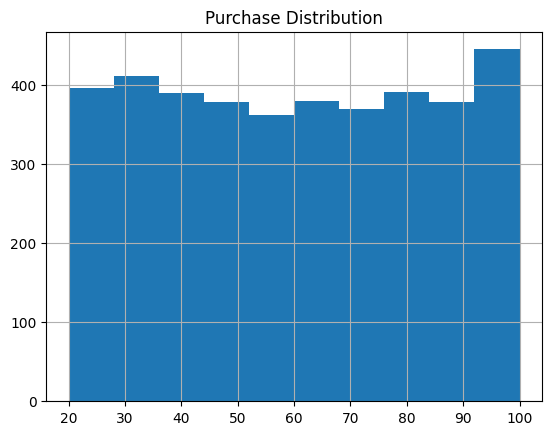

In [9]:
import matplotlib.pyplot as plt

df['Purchase Amount (USD)'].hist()
plt.title("Purchase Distribution")
plt.show()

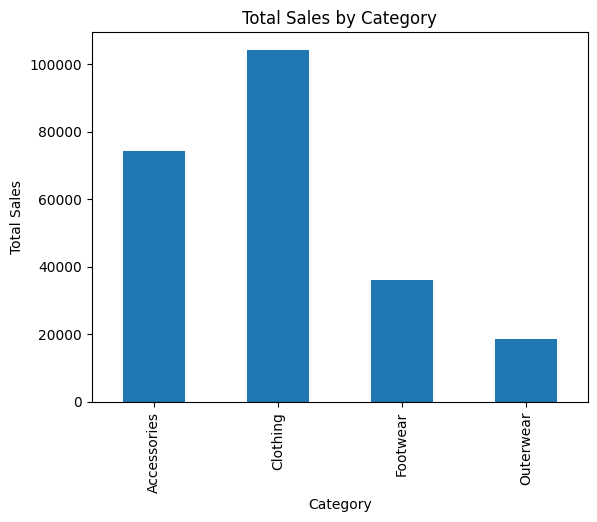

In [10]:
df.groupby('Category')['Purchase Amount (USD)'].sum().plot(kind='bar')
plt.title("Total Sales by Category")
plt.xlabel("Category")
plt.ylabel("Total Sales")
plt.show()

In [11]:
df.groupby('Category')['Purchase Amount (USD)'].sum().sort_values(ascending=False)

,Purchase Amount (USD)
Category,
Clothing,104264
Accessories,74200
Footwear,36093
Outerwear,18524


## SQL Analysis

In [12]:
import sqlite3

conn = sqlite3.connect(':memory:')
df.to_sql('sales', conn, index=False)

3900

In [13]:
query = """
SELECT Category, SUM([Purchase Amount (USD)]) as Total_Sales
FROM sales
GROUP BY Category
ORDER BY Total_Sales DESC
"""
pd.read_sql(query, conn)

,Category,Total_Sales
0,Clothing,104264
1,Accessories,74200
2,Footwear,36093
3,Outerwear,18524


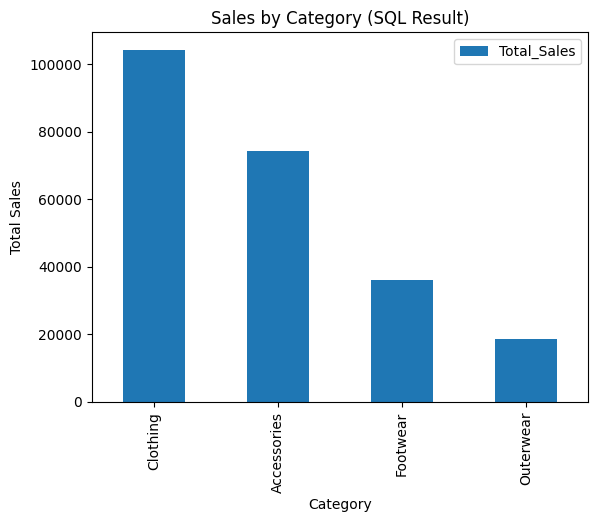

In [14]:
result = pd.read_sql(query, conn)

result.plot(x='Category', y='Total_Sales', kind='bar')
plt.title("Sales by Category (SQL Result)")
plt.ylabel("Total Sales")
plt.show()

In [15]:
query2 = """
SELECT Category, AVG([Purchase Amount (USD)]) as Avg_Sales
FROM sales
GROUP BY Category
"""
pd.read_sql(query2, conn)

,Category,Avg_Sales
0,Accessories,59.838710
1,Clothing,60.025331
2,Footwear,60.255426
3,Outerwear,57.172840


In [17]:
query4 = """
SELECT Age, SUM([Purchase Amount (USD)]) as Total
FROM sales
GROUP BY Age
ORDER BY Total DESC
LIMIT 5
"""
pd.read_sql(query4, conn)

,Age,Total
0,49,5552
1,69,5484
2,25,5372
3,54,5282
4,41,5282


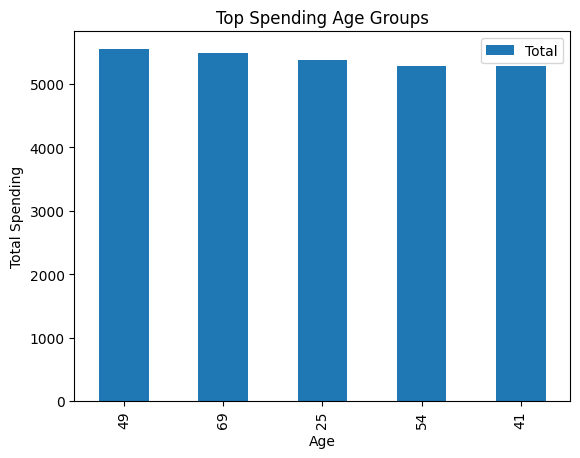

In [21]:
result2 = pd.read_sql(query4, conn)

result2.plot(x='Age', y='Total', kind='bar')
plt.title("Top Spending Age Groups")
plt.ylabel("Total Spending")
plt.show()

In [20]:
df.to_csv("final_data.csv", index=False)

In [22]:
df = pd.read_csv("final_data.csv")
df.head()

,Customer ID,Age,Gender,Item Purchased,Category,Purchase Amount (USD),Location,Size,Color,Season,Review Rating,Subscription Status,Payment Method,Shipping Type,Discount Applied,Promo Code Used,Previous Purchases,Preferred Payment Method,Frequency of Purchases
0,1,55,Male,Blouse,Clothing,53,Kentucky,L,Gray,Winter,3.1,Yes,Credit Card,Express,Yes,Yes,14,Venmo,Fortnightly
1,2,19,Male,Sweater,Clothing,64,Maine,L,Maroon,Winter,3.1,Yes,Bank Transfer,Express,Yes,Yes,2,Cash,Fortnightly
2,3,50,Male,Jeans,Clothing,73,Massachusetts,S,Maroon,Spring,3.1,Yes,Cash,Free Shipping,Yes,Yes,23,Credit Card,Weekly
3,4,21,Male,Sandals,Footwear,90,Rhode Island,M,Maroon,Spring,3.5,Yes,PayPal,Next Day Air,Yes,Yes,49,PayPal,Weekly
4,5,45,Male,Blouse,Clothing,49,Oregon,M,Turquoise,Spring,2.7,Yes,Cash,Free Shipping,Yes,Yes,31,PayPal,Annually


In [23]:
df.isnull().sum()

,0
Customer ID,0
Age,0
Gender,0
Item Purchased,0
Category,0
Purchase Amount (USD),0
Location,0
Size,0
Color,0
Season,0


In [24]:
df.shape

(3900, 19)

In [25]:
df.describe()

,Customer ID,Age,Purchase Amount (USD),Review Rating,Previous Purchases
count,3900.000000,3900.000000,3900.000000,3900.000000,3900.000000
mean,1950.500000,44.068462,59.764359,3.749949,25.351538
std,1125.977353,15.207589,23.685392,0.716223,14.447125
min,1.000000,18.000000,20.000000,2.500000,1.000000
25%,975.750000,31.000000,39.000000,3.100000,13.000000
50%,1950.500000,44.000000,60.000000,3.700000,25.000000
75%,2925.250000,57.000000,81.000000,4.400000,38.000000
max,3900.000000,70.000000,100.000000,5.000000,50.000000


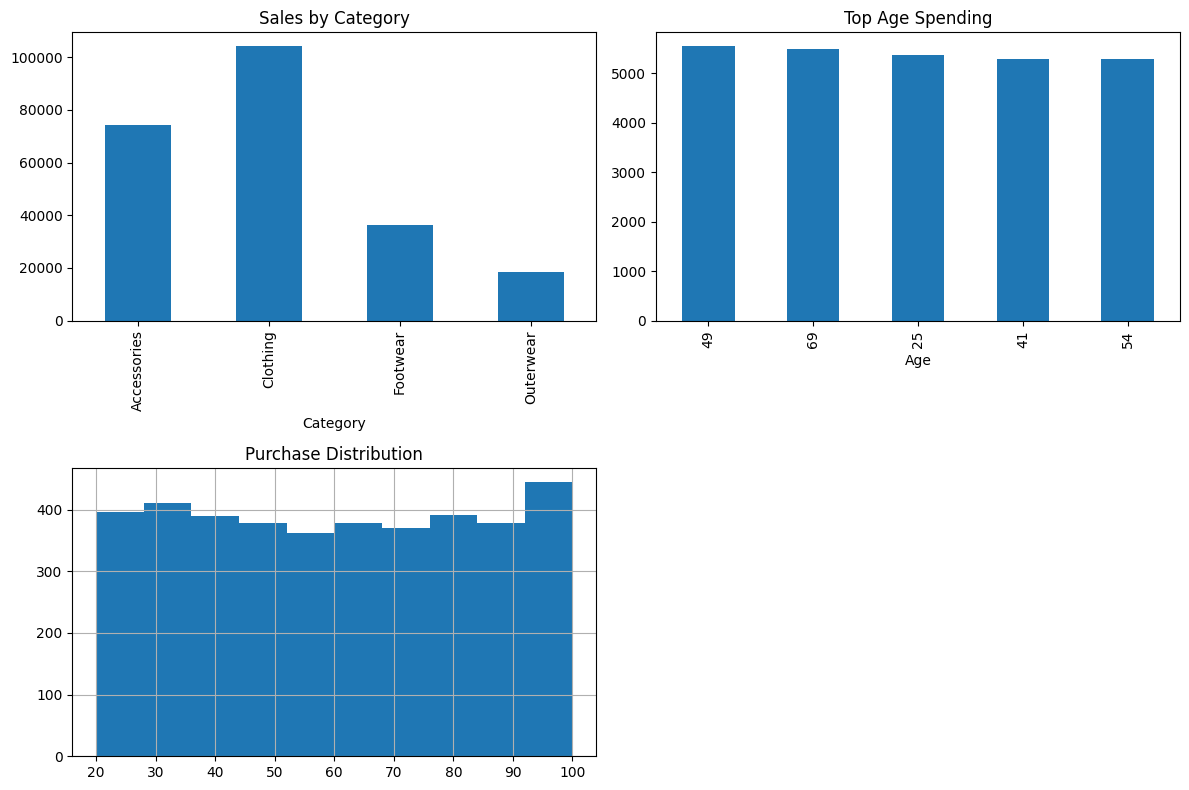

In [26]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,8))

# 1. Category chart
plt.subplot(2,2,1)
df.groupby('Category')['Purchase Amount (USD)'].sum().plot(kind='bar')
plt.title("Sales by Category")

# 2. Age chart
plt.subplot(2,2,2)
df.groupby('Age')['Purchase Amount (USD)'].sum().sort_values(ascending=False).head(5).plot(kind='bar')
plt.title("Top Age Spending")

# 3. Histogram
plt.subplot(2,2,3)
df['Purchase Amount (USD)'].hist()
plt.title("Purchase Distribution")

plt.tight_layout()
plt.show()

## Dashboard

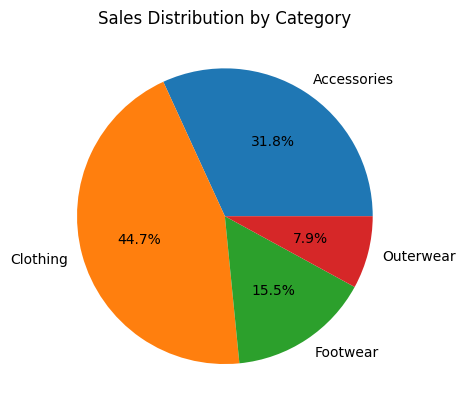

In [27]:
import matplotlib.pyplot as plt

# Category sales
category_sales = df.groupby('Category')['Purchase Amount (USD)'].sum()

plt.figure()
plt.pie(category_sales, labels=category_sales.index, autopct='%1.1f%%')

plt.title("Sales Distribution by Category")
plt.show()

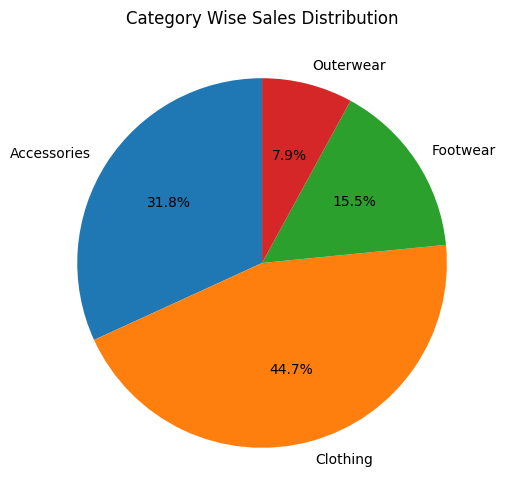

In [28]:
plt.figure(figsize=(6,6))
plt.pie(category_sales, labels=category_sales.index, autopct='%1.1f%%', startangle=90)
plt.title("Category Wise Sales Distribution")
plt.show()

## Insights
- Clothing has highest sales
- Outerwear lowest
- Age 40–70 spends more

## Conclusion
The analysis helps understand customer behavior and supports decision-making.